---
title: "Gaussian Convolution"
author: 
    - name: Oliver Hüttenhofer
date: "2026-05-01"
categories: [code, gaussian convolution, linear algebra, block encodings, toeplitz matrix]
image: "preview.png"
format:
  html:
    code-fold: false
    toc: true
    cap-location: bottom
jupyter: unitaria
code-annotations: hover
---

In this tutorial, we will see how convolutions can be implemented in Unitaria. The matrix representation of a block encoding is a Toeplitz matrix, and while it is known how these types of matrices can be block encoded ([Sünderhauf et al., 2024](https://doi.org/10.22331/q-2024-01-11-1226)), constructing the full circuit is not trivial. Unitaria can simplify this process by abstracting away low-level details.

The block encoding is shown in the following diagram:

<img src="img/toeplitz_matrix_block_encoding.svg" width="50%">

For details on why this circuit yields the correct result refer to the paper referenced above, here we will focus on the implementation in Unitaria.

First, we need some imports:

In [1]:
import numpy as np
import unitaria as ut
import matplotlib.pyplot as plt

Assume we have a three qubit state and want to perform a Gaussian convolution with the following kernel:

In [2]:
kernel = np.exp(-(np.arange(-3, 4) ** 2) / 4)
print(kernel)

[0.10539922 0.36787944 0.77880078 1.         0.77880078 0.36787944
 0.10539922]


Then the PREP block needs to prepare a vector containing the square roots of the kernel. We also need it to be a power of two, so we pad it with an extra `0`.

This prepare operation is provided by Unitaria through the `ConstantVector` node:

In [3]:
padded_kernel = np.append(kernel, 0)
prep = ut.ConstantVector(np.sqrt(padded_kernel))

Next, we have the `+s` block, which indicates an integer addition from the `s` register to the state register. Because the three qubit state is extended by an overflow qubit, we are adding a two qubit register to a four qubit register.
This operation is also provided by Unitaria:

In [4]:
add = ut.IntegerAddition(source_bits=3, target_bits=4)

The last remaining component is the `-k` block, where the constant `k` is subtracted from the state register to account for the offset of the kernel. In our case we have a seven element kernel, so to center it, the fourth element, should be in the middle. Because this has index 3, we need to subtract 3 with Unitaria's ConstantAddition node:

In [5]:
const_add = ut.ConstantIntegerAddition(bits=4, constant=-3)

The UNPREP block is the adjoint of the PREP block, so it can be directly constructed from that. But before we do that, note that both these operations only act on the top register, while ignoring the other two. If we want to combine them with the other operations, they need to act on the same set of qubits, which we can achieve by building the tensor product with an identity operation for the unused registers:

In [6]:
prep = ut.Identity(ut.Subspace.from_dim(16)) & prep

Now Unitaria makes it easy to construct the Adjoint:

In [7]:
unprep = ut.Adjoint(prep)

Same as with the PREP operation, the constant addition acts only on the last two registers, so we need to build the tensor product with the identity. Note that now the identity is on the right (i.e. the less significant register), unlike before where it was on the left. The order of operands is important here.

In [8]:
const_add = const_add & ut.Identity(ut.Subspace.from_dim(8))

Now we can combine all the operations we built. Like with matrix multiplications, multiplied nodes are evaluated from right to left.

In [9]:
convolution = unprep @ const_add @ add @ prep

One thing to note is that the most significant qubit is an ancilla, which must start and end in the state |0>. Since this qubit is zero in exactly the first 8 basis states, we can represent this by taking a slice of the operation:

In [10]:
convolution = convolution[:8, :8]

Now we have the full operation, and can apply it to some vector.
For example consider the convolution of a delta function:

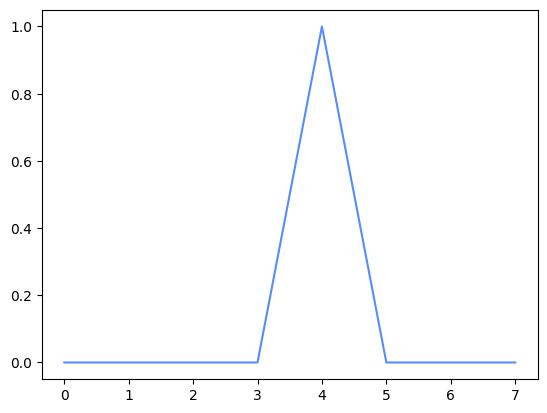

In [11]:
x = np.arange(8)
y = np.zeros(8)
y[4] = 1.0
plt.plot(x, y)

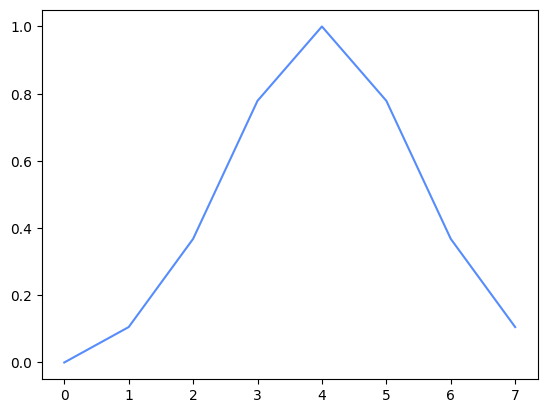

In [12]:
output = np.real(convolution.compute(y))
plt.plot(x, output)

This already looks like the expected smoothing operation, but to be sure, we can calculate the operation in Numpy to confirm it is the correct output:

In [13]:
expected = np.convolve(y, kernel, mode="same")
assert np.allclose(output, expected)